In [1]:
# 绘制中国省份的代码
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import seaborn as sns
from matplotlib.patches import Patch
from cnmaps import get_adm_maps, draw_maps, clip_pcolormesh_by_map

PROVINCE_FULL_NAME_TO_SHORT_NAME_MAP =  {
    '北京市': '北京',
    '天津市': '天津',
    '河北省': '河北',
    '山西省': '山西',
    '内蒙古自治区': '内蒙古',
    '辽宁省': '辽宁',
    '吉林省': '吉林',
    '黑龙江省': '黑龙江',
    '上海市': '上海',
    '江苏省': '江苏',
    '浙江省': '浙江',
    '安徽省': '安徽',
    '福建省': '福建',
    '江西省': '江西',
    '山东省': '山东',
    '河南省': '河南',
    '湖北省': '湖北',
    '湖南省': '湖南',
    '广东省': '广东',
    '广西壮族自治区': '广西',
    '海南省': '海南',
    '重庆市': '重庆',
    '四川省': '四川',
    '贵州省': '贵州',
    '云南省': '云南',
    '西藏自治区': '西藏',
    '陕西省': '陕西',
    '甘肃省': '甘肃',
    '青海省': '青海',
    '宁夏回族自治区': '宁夏',
    '新疆维吾尔自治区': '新疆',
    '台湾省': '台湾',
    '香港特别行政区': '香港',
}

PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP = {v:k for k,v in PROVINCE_FULL_NAME_TO_SHORT_NAME_MAP.items()}
PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP
def plot_china_provinces(

    data,
    province: str,
    group: str,
    china_provinces=None,   # ✅ 改这里
    group_order=None,
    palette=None,
    color=None,
    lw = 0.8,
    line_color = "black",
    legend: bool = True,
    legend_title: str | None = None,
    geom_kws: dict | None = None,
    geom_kws_by_name: dict | None = None,
    legend_kws: dict | None = None,
    legend_handles_kws: dict | None = None,
    ax=None,
    figsize = (6,4),
    dpi = 300
):
    """
    Province 应该是全称，如北京市，台湾省等
    """
    if ax is None:
        fig = plt.figure(figsize=figsize, dpi=dpi)
        ax = plt.axes(projection=ccrs.PlateCarree())
    # ==== 0. map init（关键新增）====
    if china_provinces is None:
        china_provinces = get_adm_maps(
            country="中华人民共和国",
            level="省",
            only_polygon=False
        )

    geom_kws = {} if geom_kws is None else dict(geom_kws)
    geom_kws_by_name = {} if geom_kws_by_name is None else dict(geom_kws_by_name)
    legend_kws = {} if legend_kws is None else dict(legend_kws)
    legend_handles_kws = {} if legend_handles_kws is None else dict(legend_handles_kws)


    # ==== 1. group order ====
    groups = list(group_order) if group_order is not None else list(data[group].unique())

    # ==== 2. color mapping（完全对齐你的 barplot 逻辑）====
    if palette is not None:
        if isinstance(palette, dict):
            color_map = palette
        else:
            colors = (
                palette
                if isinstance(palette, (list, tuple))
                else sns.color_palette(palette, len(groups))
            )
            color_map = {g: colors[i % len(colors)] for i, g in enumerate(groups)}
    else:
        base_color = color if color is not None else sns.color_palette("Set2", 1)[0]
        color_map = {g: base_color for g in groups}

    # ==== 3. province -> group ====
    province_to_group = dict(zip(data[province], data[group]))

    # ==== 4. axis ====
    ax.set_extent([73, 136, 18, 54], crs=ccrs.PlateCarree())

    # ==== 5. draw ====
    for prov in china_provinces:
        name = prov["province"]
        poly = prov.geometry.geom

        g = province_to_group.get(name, None)

        # --- default geom
        default_geom = {
            "facecolor": color_map.get(g, "lightgrey"),
            "edgecolor": "black",
            "linewidth": 0.5,
            "alpha": 0.9,
            "zorder": 1,
        }

        # --- merge（和你 barplot 完全一致）
        merged_geom = {
            **default_geom,
            **geom_kws,
            **geom_kws_by_name.get(name, {}),
        }

        ax.add_geometries(
            [poly],
            crs=ccrs.PlateCarree(),
            **merged_geom,
        )

    # ==== 6. boundary ====
    draw_maps(china_provinces, linewidth=lw, color=line_color, ax=ax)

    # ==== 7. legend ====
    if legend:

        # --- default handle（控制 Patch 样式）
        default_handle = {
            "edgecolor": "black",
            "linewidth": 0.8,
        }

        merged_handle = {
            **default_handle,
            **legend_handles_kws,
        }

        handles = [
            Patch(
                facecolor=color_map[g],
                label=str(g),
                **merged_handle
            )
            for g in groups
        ]

        # --- default legend（整体 legend 样式）
        default_legend = {
            "title": legend_title or group,
            "fontsize": 7,
            "title_fontsize": 8,
            "frameon": False,
        }

        merged_legend = {
            **default_legend,
            **legend_kws,
        }

        ax.legend(
            handles=handles,
            **merged_legend,
        )



    return ax


In [2]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

from tqdm import tqdm
import torch


def predict_forecasts(
    model,
    data,
    target,
    # horizon=None,
    # lookback=None,
    device="cpu",
    target_normalizer=None,
    batch_size=64,
):
    """
    Rolling multi-step forecasting.

    Strictly preserves the original windowing logic:
        for i in range(0, len(data) - horizon - lookback, horizon):
            history = data[i:i + lookback]
            label = target[i + lookback:i + lookback + horizon]

    Returns
    -------
    predictions : torch.Tensor
        Flattened predictions.
    groundtruth : torch.Tensor
        Flattened ground truth.
    label_indices : list[int]
        Flattened time indices aligned with predictions / groundtruth.
    """
    horizon = model.horizon if hasattr(model, 'horizon') else None 
    lookback =  model.lookback if hasattr(model, 'lookback') else None 

    if horizon is None or lookback is None:
        raise ValueError("`horizon` and `lookback` must be provided.")
    if batch_size <= 0:
        raise ValueError("`batch_size` must be a positive integer.")

    data = torch.as_tensor(data, dtype=torch.float32)
    target = torch.as_tensor(target, dtype=torch.float32)

    histories, labels, start_indices = _build_forecast_windows(
        data=data,
        target=target,
        lookback=lookback,
        horizon=horizon,
    )

    prediction_chunks = []
    groundtruth_chunks = []
    label_indices = []
    if hasattr(model, "to"):
        model.to(device)
    # else:

    with torch.no_grad():
        for start in tqdm(range(0, histories.shape[0], batch_size)):
            end = min(start + batch_size, histories.shape[0])

            batch_history = histories[start:end]
            batch_label = labels[start:end]

            preds = _run_model_predict(
                model=model,
                batch_history=batch_history,
                device=device,
            )
            preds = preds.detach().cpu()
            preds = _maybe_inverse_transform(preds, target_normalizer)

            preds = _normalize_prediction_shape(preds)
            batch_label = _normalize_prediction_shape(batch_label)

            if preds.shape != batch_label.shape:
                raise ValueError(
                    f"Prediction shape {tuple(preds.shape)} does not match "
                    f"label shape {tuple(batch_label.shape)}."
                )

            for b in range(preds.shape[0]):
                pred_item = preds[b].reshape(-1)
                label_item = batch_label[b].reshape(-1)

                if pred_item.numel() != label_item.numel():
                    raise ValueError(
                        f"Prediction length ({pred_item.numel()}) does not match "
                        f"label length ({label_item.numel()})."
                    )

                prediction_chunks.append(pred_item)
                groundtruth_chunks.append(label_item)

                i = start_indices[start + b]
                label_indices.extend(range(i + lookback, i + lookback + horizon))

    predictions = torch.cat(prediction_chunks, dim=0)
    groundtruth = torch.cat(groundtruth_chunks, dim=0)

    return predictions, groundtruth, label_indices


def _build_forecast_windows(data, target, lookback, horizon):
    """
    按原始逻辑构造 rolling forecasting windows.
    """
    history_chunks = []
    label_chunks = []
    start_indices = []

    for i in range(0, len(data) - horizon - lookback, horizon):
        history = data[i:i + lookback]
        label = target[i + lookback:i + lookback + horizon]

        history_chunks.append(history)
        label_chunks.append(label)
        start_indices.append(i)

    if not history_chunks:
        raise ValueError("No valid forecasting windows were generated.")

    histories = torch.stack(history_chunks, dim=0)
    labels = torch.stack(label_chunks, dim=0)

    return histories, labels, start_indices


def _run_model_predict(model, batch_history, device="cpu"):
    """
    兼容 torch model 和 sklearn-like model 的预测接口.
    """
    batch_history = batch_history.to(device)
    if not hasattr(model, "to") and hasattr(model, "predict"):
        # sklearn / xgboost / tabpfn 风格
        output = model.predict(batch_history)
    else:
        # torch / lightning 风格
        batch_history = batch_history.to(device)
        output = model(batch_history)

    return torch.as_tensor(output, dtype=torch.float32)


def _maybe_inverse_transform(preds, target_normalizer=None):
    """
    对预测结果做反归一化，并尽量兼容 torch / numpy 输出.
    """
    if target_normalizer is None:
        return torch.as_tensor(preds, dtype=torch.float32)

    preds_inv = target_normalizer.inverse_transform(preds)
    return torch.as_tensor(preds_inv, dtype=torch.float32)


def _normalize_prediction_shape(x):
    """
    将张量统一为:
    - (B, H)     for single-target
    - (B, H, D)  for multi-target

    当前逻辑：
    - 若为 (B, H, 1)，压成 (B, H)
    - 其他情况保持不变
    """
    x = torch.as_tensor(x, dtype=torch.float32)

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x.squeeze(-1)

    return x

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

def batch_forecast_eval(
    model, 
    data_bundle, 
    dataset_names=["test"], 
    num_cities=3, 
    batch_size=256, 
    device="cpu",
    plot=True,

):
    """
    批量进行城市预测、评估，并将所有图组合在一个 subplots 中。
    """
    # ====== 环境准备 ======

    city_order = data_bundle.all_city_names
    y_normalizer = data_bundle.y_normalizer
    time_index_all = data_bundle.time_index
    x_transformed = data_bundle.x_normalizer.transform(data_bundle.raw_x)
    y_raw = data_bundle.raw_y

    # 确定需要预测的所有城市任务清单
    task_list = []
    for dataset_name in dataset_names:
        if isinstance(num_cities, int):
            target_cities = data_bundle.city_name_dict.get(dataset_name, [])[:num_cities]
        else:
            target_cities = data_bundle.city_name_dict.get(dataset_name, [])
        for city_name in target_cities:
            task_list.append((dataset_name, city_name))

    total_tasks = len(task_list)
    if total_tasks == 0:
        return pd.DataFrame()

    # ====== 初始化 Subplots 画布 ======
    if plot:

        fig, axes = plt.subplots(1, num_cities, figsize=(5 * num_cities, 3.5 ), dpi=300)
        axes = axes.flatten() if total_tasks > 1 else [axes]
    
    all_dfs = []

    # ====== 遍历任务执行预测 ======
    for i, (dataset_name, city_name) in enumerate(task_list):
        k = city_order.index(city_name)
        data_used_x = x_transformed[:, k]
        target_used_y = y_raw[:, k]

        # 调用预测函数
        predictions, groundtruth, label_indices = predict_forecasts(
            model=model, data=data_used_x, target=target_used_y,
           device=device,
            target_normalizer=y_normalizer, batch_size=batch_size,
        )

        preds_np = predictions.detach().cpu().numpy()
        labels_np = groundtruth.detach().cpu().numpy()
        mse = mean_squared_error(labels_np, preds_np)
        mae = mean_absolute_error(labels_np, preds_np)

        time_index = pd.to_datetime([time_index_all[idx] for idx in label_indices])
        df = pd.DataFrame({
            "Time": time_index, "Preds": preds_np, "Labels": labels_np,
            "City": city_name, "Dataset": dataset_name
        })
        all_dfs.append(df)

        # ====== 绘图填充 ======
        if plot:
            ax = axes[i]
            _plot_on_ax(df, ax, city_name, dataset_name, mse)

    # 关闭多余的子图刻度
    if plot:
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
        plt.tight_layout()
        plt.show()

    return pd.concat(all_dfs, ignore_index=True)

def _plot_on_ax(df, ax, city_name, dataset_name, mse):
    """将预测结果绘制在指定的子图坐标轴(ax)上"""
    plot_df = df.melt(
        id_vars=["Time"], value_vars=["Preds", "Labels"],
        var_name="Type", value_name="Value"
    )
    
    sns.lineplot(
        data=plot_df, x="Time", y="Value", hue="Type", style="Type",
        palette={"Preds": "grey", "Labels": "red"},
        style_order=["Preds", "Labels"], ax=ax
    )
    ax.set_title(f"{city_name} ({dataset_name})\nMSE: {mse:.4f}", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel("")
    ax.set_ylabel("Value")



In [3]:
# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']   # 黑体
# 解决负号显示异常
matplotlib.rcParams['axes.unicode_minus'] = False



In [4]:
from EpiAI.dataset.io import load_disease_tensor 
from EpiAI.dataset.inspector import DatasetInspector
raw_data = load_disease_tensor("data/Align_data_tensor_with_name.pt")
inspector = DatasetInspector(raw_data)

features =inspector.show_features()


Available features:
  [0] 乙脑
  [1] 疟疾
  [2] 登革热
  [3] u10_mean
  [4] u10_max
  [5] u10_min
  [6] sp_mean
  [7] sp_max
  [8] sp_min
  [9] ssrdc_mean
  [10] ssrdc_max
  [11] ssrdc_min
  [12] t2m_mean
  [13] t2m_max
  [14] t2m_min
  [15] swvl2_mean
  [16] swvl2_max
  [17] swvl2_min
  [18] d2m_mean
  [19] d2m_max
  [20] d2m_min
  [21] v10_mean
  [22] v10_max
  [23] v10_min
  [24] swvl1_mean
  [25] swvl1_max
  [26] swvl1_min
  [27] skt_mean
  [28] skt_max
  [29] skt_min
  [30] tp_mean
  [31] tp_max
  [32] tp_min
  [33] ssrd_mean
  [34] ssrd_max
  [35] ssrd_min
  [36] tcc_mean
  [37] tcc_max
  [38] tcc_min
  [39] ws10_mean
  [40] ws10_max
  [41] ws10_min
  [42] month_sin
  [43] month_cos
  [44] year_idx_norm
  [45] is_warm_season


In [5]:
inspector.coords['Year/Month']

[datetime.datetime(2004, 1, 1, 0, 0),
 datetime.datetime(2004, 2, 1, 0, 0),
 datetime.datetime(2004, 3, 1, 0, 0),
 datetime.datetime(2004, 4, 1, 0, 0),
 datetime.datetime(2004, 5, 1, 0, 0),
 datetime.datetime(2004, 6, 1, 0, 0),
 datetime.datetime(2004, 7, 1, 0, 0),
 datetime.datetime(2004, 8, 1, 0, 0),
 datetime.datetime(2004, 9, 1, 0, 0),
 datetime.datetime(2004, 10, 1, 0, 0),
 datetime.datetime(2004, 11, 1, 0, 0),
 datetime.datetime(2004, 12, 1, 0, 0),
 datetime.datetime(2005, 1, 1, 0, 0),
 datetime.datetime(2005, 2, 1, 0, 0),
 datetime.datetime(2005, 3, 1, 0, 0),
 datetime.datetime(2005, 4, 1, 0, 0),
 datetime.datetime(2005, 5, 1, 0, 0),
 datetime.datetime(2005, 6, 1, 0, 0),
 datetime.datetime(2005, 7, 1, 0, 0),
 datetime.datetime(2005, 8, 1, 0, 0),
 datetime.datetime(2005, 9, 1, 0, 0),
 datetime.datetime(2005, 10, 1, 0, 0),
 datetime.datetime(2005, 11, 1, 0, 0),
 datetime.datetime(2005, 12, 1, 0, 0),
 datetime.datetime(2006, 1, 1, 0, 0),
 datetime.datetime(2006, 2, 1, 0, 0),
 datet

In [6]:
provinces = inspector.coords['province']
provinces

['上海',
 '云南',
 '内蒙古',
 '北京',
 '吉林',
 '四川',
 '天津',
 '宁夏',
 '安徽',
 '山东',
 '山西',
 '广东',
 '广西',
 '新疆',
 '江苏',
 '江西',
 '河北',
 '河南',
 '浙江',
 '海南',
 '湖北',
 '湖南',
 '甘肃',
 '福建',
 '西藏',
 '贵州',
 '辽宁',
 '重庆',
 '陕西',
 '青海',
 '黑龙江']

<GeoAxes: >

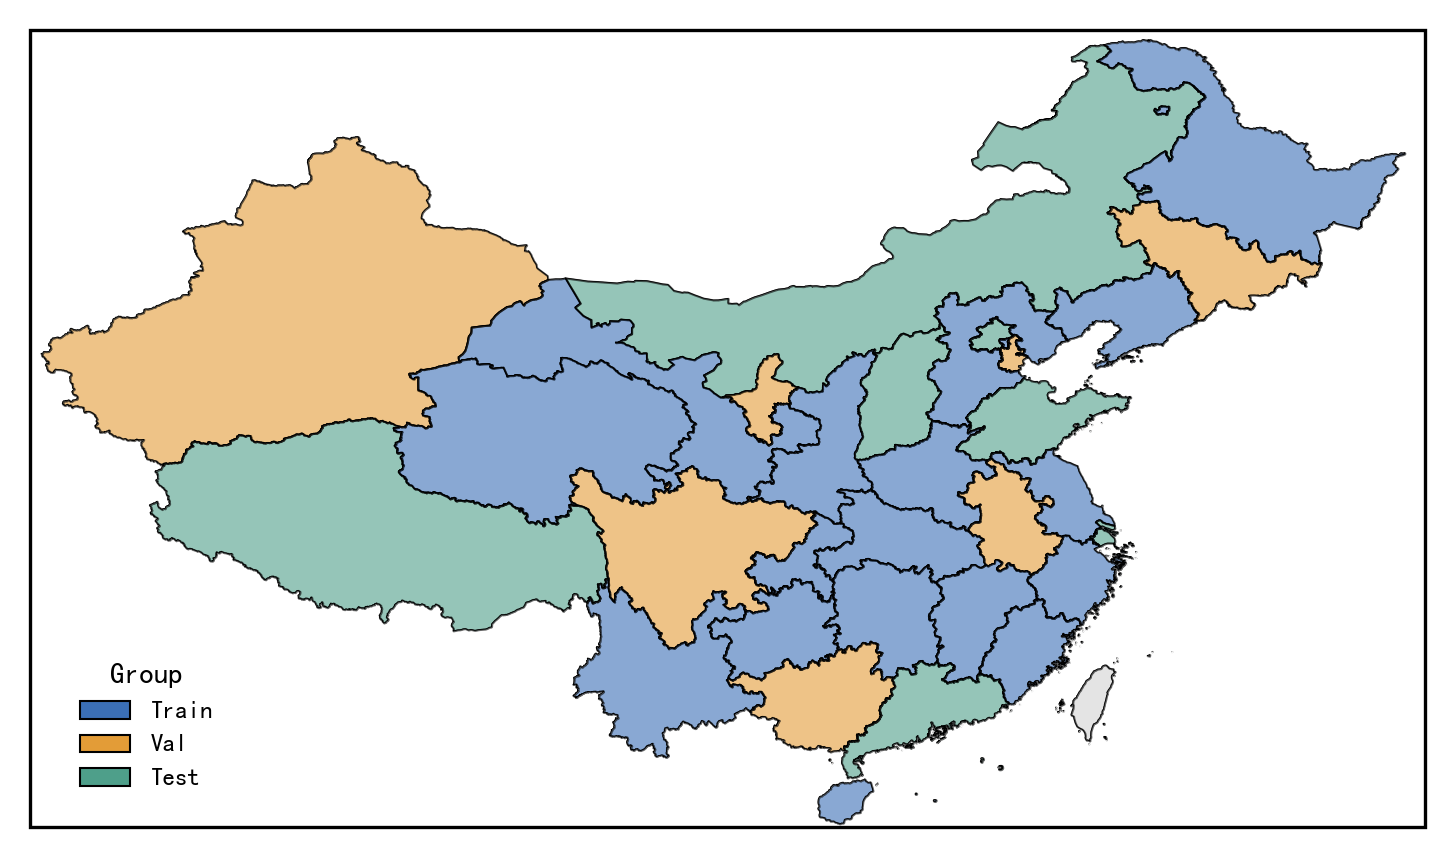

In [7]:
import pandas as pd

province_split_list = {
    'Train': [ '江西', '湖南', '贵州','云南', '浙江', '海南', '福建', '江苏', '河北', '河南', 
              '湖北', '甘肃',  '辽宁', '重庆', '陕西', '青海', '黑龙江'],
    'Val': ['吉林', '四川', '天津', '宁夏', '安徽', '新疆','广西',],
    'Test': ['上海', '内蒙古', '北京', '山东', '山西', '广东','西藏',]
}

train_indices = [provinces.index(i) for i in province_split_list['Train']]    # 云南、浙江、海南、福建
val_indices = [provinces.index(i) for i in province_split_list['Val']]    
test_indices = [provinces.index(i) for i in province_split_list['Test']]    

df = pd.DataFrame(list(province_split_list.items()), columns=['split', 'province'])

# 3. 使用 explode 方法将列表展开成多行
df = df.explode('province').reset_index(drop=True)
df['province'] = df['province'].replace(PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP)
# 打印结果

plot_china_provinces(
    data=df,
    province="province",
    group="split",
    palette = {
        "Train": "#3B6FB6",
        "Val":   "#E39C37",
        "Test":  "#4E9F8A",
    },
    geom_kws={"alpha":0.6},
    lw= 0.2,
    legend_kws=dict(
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        fontsize=6,
        ncol=1,
        title_fontsize=7,
 
        frameon=False,
        title='Group'
    ),
    legend_handles_kws=dict(
    edgecolor="black",
    linewidth=.5
)
)


In [8]:
used_features = ['乙脑', '疟疾', '登革热', 'u10_mean', 'u10_max', 'u10_min', 'sp_mean', 'sp_max', 'sp_min', 'ssrdc_mean', 'ssrdc_max', 'ssrdc_min', 't2m_mean', 't2m_max', 't2m_min', 'swvl2_mean', 'swvl2_max', 'swvl2_min', 'd2m_mean', 'd2m_max', 'd2m_min', 'v10_mean', 'v10_max', 'v10_min', 'swvl1_mean', 'swvl1_max', 'swvl1_min', 'skt_mean', 'skt_max', 'skt_min', 'tp_mean', 'tp_max', 'tp_min', 'ssrd_mean', 'ssrd_max', 'ssrd_min', 'tcc_mean', 'tcc_max', 'tcc_min', 'ws10_mean', 'ws10_max', 'ws10_min']

In [9]:
from EpiAI.dataset import DatasetConfig, ForecastDataModule, MultiTargetCityDatasetBuilder
# 指定训练的省份
# train_indices = [1, 18, 19, 23, 13, 14, 16, 17, 20, 22, 24, 26, 27, 28, 29, 30]          # 云南、浙江、海南、福建
# val_indices = [ 12, 15, 21, 25, 4, 5, 6, 7, 8]       # 广东、广西、江西、湖南、贵州
# test_indices = [0, 2, 3 , 9, 10, 11,]

lookback = 12 
horizon = 3 
config = DatasetConfig(
    data_path="data/Align_data_tensor_with_name.pt",
    target_feature_names=["登革热"],
    input_feature_mode="explicit",
    input_feature_names=used_features,
    city_dim=1,
    split_mode="indices",  # cutoff
    train_city_indices = train_indices,
    val_city_indices = val_indices,
    test_city_indices = test_indices,
    lookback=lookback,
    horizon=horizon,
    ahead=0,
    normalize_x=True,
    normalize_y=True,
)

# builder = MultiTargetCityDatasetBuilder(config)
# bundle = builder.build()



In [10]:

datamodule = ForecastDataModule(
    dataset_config=config,
    batch_size=32,
    num_workers=4,
    train_shuffle=True
)

datamodule.setup("fit")
input_dim = datamodule.bundle.train_input.shape[-1]
target_dim = datamodule.bundle.train_target.shape[-1]
print(input_dim, target_dim)

42 1


In [11]:
# ## Test model 

# import torch
# import torch.nn as nn
# import lightning as L


# class ForecastLightningModule(L.LightningModule):
#     """
#     Generic LightningModule for multi-step, multi-target forecasting.

#     Model contract
#     --------------
#     The wrapped model must implement:
#         y_hat = model(x)

#     Input:
#         x.shape == (batch_size, lookback, input_dim)

#     Output:
#         y_hat.shape == (batch_size, horizon, target_dim)
#     """

#     def __init__(
#         self,
#         model: nn.Module,
#         lr: float = 1e-3,
#         weight_decay: float = 0.0,
#         loss_fn: nn.Module | None = None,
#     ) -> None:
#         super().__init__()
#         self.model = model
#         self.lr = lr
#         self.weight_decay = weight_decay
#         self.loss_fn = loss_fn if loss_fn is not None else nn.MSELoss()

#         self.save_hyperparameters(ignore=["model", "loss_fn"])

#     def forward(self, x: torch.Tensor) -> torch.Tensor:

#         return self.model(x)   

#     def _shared_step(self, batch, stage: str):
#         x, y = batch
#         y_hat = self(x)

#         if y_hat.shape != y.shape:
            
#             raise ValueError(
#                 f"{stage}: prediction shape {tuple(y_hat.shape)} does not match "
#                 f"target shape {tuple(y.shape)}."
#             )

#         loss = self.loss_fn(y_hat, y)

#         mae = torch.mean(torch.abs(y_hat - y))
#         rmse = torch.sqrt(torch.mean((y_hat - y) ** 2))
#         mse = torch.mean((y_hat - y) ** 2)

#         self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
#         self.log(f"{stage}_mae", mae, prog_bar=True, on_step=False, on_epoch=True)
#         self.log(f"{stage}_rmse", rmse, prog_bar=True, on_step=False, on_epoch=True)
#         self.log(f"{stage}_mse", mse, prog_bar=True, on_step=False, on_epoch=True)

#         return loss

#     def training_step(self, batch, batch_idx: int):
#         return self._shared_step(batch, stage="train")

#     def validation_step(self, batch, batch_idx: int):
#         self._shared_step(batch, stage="val")

#     def test_step(self, batch, batch_idx: int):
#         self._shared_step(batch, stage="test")

#     def configure_optimizers(self):
#         optimizer = torch.optim.Adam(
#             self.parameters(),
#             lr=self.lr,
#             weight_decay=self.weight_decay,
#         )
#         return optimizer



In [12]:
import copy
import math
import os
from dataclasses import dataclass
from typing import Optional, Dict, Any

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm 

# =========================
# 1. Device
# =========================
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


# =========================
# 2. EarlyStopping
# =========================
class EarlyStopping:
    def __init__(
        self,
        monitor: str = "val_loss",
        mode: str = "min",
        patience: int = 10,
        min_delta: float = 0.0,
        restore_best_weights: bool = True,
    ):
        assert mode in ["min", "max"]
        self.monitor = monitor
        self.mode = mode
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.best_score = None
        self.best_state_dict = None
        self.counter = 0
        self.should_stop = False

    def _is_improvement(self, current: float, best: float) -> bool:
        if self.mode == "min":
            return current < best - self.min_delta
        else:
            return current > best + self.min_delta

    def step(self, current_score: float, model: nn.Module):
        if self.best_score is None:
            self.best_score = current_score
            if self.restore_best_weights:
                self.best_state_dict = copy.deepcopy(model.state_dict())
            return

        if self._is_improvement(current_score, self.best_score):
            self.best_score = current_score
            self.counter = 0
            if self.restore_best_weights:
                self.best_state_dict = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore(self, model: nn.Module):
        if self.restore_best_weights and self.best_state_dict is not None:
            model.load_state_dict(self.best_state_dict)


# =========================
# 3. Train config
# =========================
@dataclass
class TrainConfig:
    max_epochs: int = 50
    lr: float = 1e-3
    weight_decay: float = 1e-3
    grad_clip_val: Optional[float] = 1.0
    patience: int = 10
    min_delta: float = 0.0
    monitor: str = "val_loss"
    monitor_mode: str = "min"
    use_scheduler: bool = False
    scheduler_patience: int = 5
    scheduler_factor: float = 0.5
    save_best_path: Optional[str] = "best_model.pt"
    print_every_epoch: bool = True


# =========================
# 4. One epoch: train
# =========================
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: torch.device,
    grad_clip_val: Optional[float] = None,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        # 这里假设 dataloader 返回 (x, y)
        # 如果你的是别的格式，我下面会告诉你怎么改
        x, y = batch
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()

        if grad_clip_val is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_val)

        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    return avg_loss


# =========================
# 5. One epoch: validate
# =========================
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        x, y = batch
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    return avg_loss


# =========================
# 6. Main fit function
# =========================
def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    loss_fn: nn.Module,
    config: TrainConfig,
    optimizer: Optional[torch.optim.Optimizer] = None,
):
    device = get_device()
    model = model.to(device)

    if optimizer is None:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay,
        )

    scheduler = None
    if config.use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=config.monitor_mode,
            patience=config.scheduler_patience,
            factor=config.scheduler_factor,
        )

    early_stopper = EarlyStopping(
        monitor=config.monitor,
        mode=config.monitor_mode,
        patience=config.patience,
        min_delta=config.min_delta,
        restore_best_weights=True,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "best_val_loss": math.inf if config.monitor_mode == "min" else -math.inf,
    }

    print(f"Using device: {device}")

    for epoch in tqdm(range(1, (config.max_epochs + 1))):
        train_loss = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
            grad_clip_val=config.grad_clip_val,
        )

        val_loss = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            loss_fn=loss_fn,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if config.print_every_epoch:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch [{epoch}/{config.max_epochs}] "
                f"train_loss={train_loss:.6f} "
                f"val_loss={val_loss:.6f} "
                f"lr={current_lr:.6e}"
            )

        # scheduler
        if scheduler is not None:
            scheduler.step(val_loss)

        # save best
        improved = False
        if config.monitor_mode == "min":
            if val_loss < history["best_val_loss"]:
                history["best_val_loss"] = val_loss
                improved = True
        else:
            if val_loss > history["best_val_loss"]:
                history["best_val_loss"] = val_loss
                improved = True

        if improved and config.save_best_path is not None:
            os.makedirs(os.path.dirname(config.save_best_path) or ".", exist_ok=True)
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": copy.deepcopy(model.state_dict()),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                },
                config.save_best_path,
            )

        # early stopping
        early_stopper.step(val_loss, model)
        if early_stopper.should_stop:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    # restore best weights in memory
    early_stopper.restore(model)

    print(f"Best val_loss: {early_stopper.best_score:.6f}")
    return model, history


# =========================
# 7. Example usage
# =========================
# 假设你已经有：
# model
# datamodule
# 并且 datamodule 有 train_dataloader() / val_dataloader()

# model = ...
# datamodule = ...

# loss_fn = nn.HuberLoss()

# config = TrainConfig(
#     max_epochs=50,
#     lr=1e-3,
#     weight_decay=1e-3,
#     grad_clip_val=1.0,
#     patience=10,
#     min_delta=0.0,
#     use_scheduler=False,
#     save_best_path="checkpoints/best_model.pt",
# )

# trained_model, history = fit_model(
#     model=model,
#     train_loader=datamodule.train_dataloader(),
#     val_loader=datamodule.val_dataloader(),
#     loss_fn=loss_fn,
#     config=config,
# )


## 测试深度学习的模型

In [13]:
import EpiAI.models.torch_models as EpiAI_torch_models
EpiAI_torch_models.__all__

['CNNLSTMForecaster',
 'CNNForecaster',
 'DLinearForecaster',
 'LSTMForecaster',
 'MLPForecaster',
 'ResNetForecaster',
 'TCNForecaster',
 'TransformerForecaster',
 'AutoformerForecaster',
 'TimesNetForecaster']

In [ ]:
res_dict = {} 

In [44]:
cutoff = 1

cutoff_normed = datamodule.bundle.y_normalizer.transform(torch.Tensor([cutoff]).reshape(1,1,1)).numpy().flatten()[0]
cutoff_normed

np.float32(-0.08622442)

In [57]:
from pathlib import Path
from EpiAI.losses import *
default_train_config = dict(
        max_epochs=50,
        lr=5e-2,
        weight_decay=1e-3,
        grad_clip_val=1.0,
        patience=10,
        min_delta=0.0,
        use_scheduler=True,
        )

class TrendAwareLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, y_pred, y_true):
        mae_loss = torch.abs(y_pred - y_true).mean()

        pred_diff = y_pred[:, 1:] - y_pred[:, :-1]
        true_diff = y_true[:, 1:] - y_true[:, :-1]
        trend_loss = torch.abs(pred_diff - true_diff).mean()

        return self.alpha * mae_loss + self.beta * trend_loss
import torch
import torch.nn as nn

class OutbreakAwareLoss(nn.Module):
    def __init__(
        self,
        outbreak_threshold,
        alpha=1.0,          # base MAE 权重
        beta=3.0,           # outbreak loss 权重
        gamma=1.0,          # trend loss 权重
        outbreak_weight=5.0 # 爆发点额外权重
    ):
        super().__init__()
        self.outbreak_threshold = outbreak_threshold
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.outbreak_weight = outbreak_weight

    def forward(self, pred, target):
        """
        pred:   [B, H, D]
        target: [B, H, D]
        """
        # 1) 基础 MAE
        base_mae = torch.abs(pred - target).mean()

        # 2) 爆发窗口损失
        outbreak_mask = (target >= self.outbreak_threshold).float()   # [B, H, D]

        # 给爆发点更大权重
        weights = 1.0 + outbreak_mask * (self.outbreak_weight - 1.0)
        outbreak_mae = (weights * torch.abs(pred - target)).mean()

        # 3) 趋势损失（比较 horizon 内的变化）
        if target.size(1) > 1:
            pred_diff = pred[:, 1:, :] - pred[:, :-1, :]
            target_diff = target[:, 1:, :] - target[:, :-1, :]
            trend_mae = torch.abs(pred_diff - target_diff).mean()
        else:
            trend_mae = torch.tensor(0.0, device=target.device)

        loss = self.alpha * base_mae + self.beta * outbreak_mae + self.gamma * trend_mae
        return loss

class AsymmetricOutbreakLoss(nn.Module):
    def __init__(self, outbreak_threshold, alpha=1.0, beta=3.0, gamma=1.0, under_weight=2.0):
        super().__init__()
        self.outbreak_threshold = outbreak_threshold
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.under_weight = under_weight

    def forward(self, pred, target):
        base_mae = torch.abs(pred - target).mean()

        outbreak_mask = (target >= self.outbreak_threshold).float()
        outbreak_count = outbreak_mask.sum()

        if outbreak_count > 0:
            error = pred - target
            abs_error = torch.abs(error)

            # 低估：pred < target
            under_mask = (error < 0).float()

            outbreak_loss = (
                abs_error * outbreak_mask * (1.0 + under_mask * (self.under_weight - 1.0))
            ).sum() / outbreak_count
        else:
            outbreak_loss = torch.tensor(0.0, device=target.device)

        if target.size(1) > 1:
            pred_diff = pred[:, 1:, :] - pred[:, :-1, :]
            target_diff = target[:, 1:, :] - target[:, :-1, :]
            trend_loss = torch.abs(pred_diff - target_diff).mean()
        else:
            trend_loss = torch.tensor(0.0, device=target.device)

        return self.alpha * base_mae + self.beta * outbreak_loss + self.gamma * trend_loss

import torch
import torch.nn as nn
import torch.nn.functional as F


class OutbreakWeightedHuberLoss(nn.Module):
    """
    pred:   [B, H, D]
    target: [B, H, D]

    组成：
    1) base huber：整体稳定
    2) outbreak window mae：强化爆发窗口
    3) trend mae：强化窗口内升降趋势
    """
    def __init__(
        self,
        outbreak_threshold: float,
        alpha: float = 1.0,   # base huber
        beta: float = 3.0,    # outbreak window
        gamma: float = 1.0,   # trend
        delta: float = 1.0,   # huber delta
        expand_window: bool = True
    ):
        super().__init__()
        self.outbreak_threshold = outbreak_threshold
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.expand_window = expand_window

    def _expand_mask(self, mask: torch.Tensor) -> torch.Tensor:
        """
        mask: [B, H, D]
        若某一步是爆发，则前后一步也纳入爆发窗口
        """
        if not self.expand_window or mask.size(1) <= 1:
            return mask

        expanded = mask.clone()
        expanded[:, 1:, :] = torch.maximum(expanded[:, 1:, :], mask[:, :-1, :])
        expanded[:, :-1, :] = torch.maximum(expanded[:, :-1, :], mask[:, 1:, :])
        return expanded

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        assert pred.shape == target.shape, f"pred {pred.shape} != target {target.shape}"

        # 1) base huber
        base_huber = F.huber_loss(pred, target, delta=self.delta, reduction="mean")

        # 2) outbreak window mae
        raw_mask = (target >= self.outbreak_threshold).float()
        outbreak_mask = self._expand_mask(raw_mask)
        outbreak_count = outbreak_mask.sum()

        if outbreak_count > 0:
            outbreak_mae = (torch.abs(pred - target) * outbreak_mask).sum() / outbreak_count
        else:
            outbreak_mae = pred.new_tensor(0.0)

        # 3) trend mae
        if target.size(1) > 1:
            pred_diff = pred[:, 1:, :] - pred[:, :-1, :]
            target_diff = target[:, 1:, :] - target[:, :-1, :]
            trend_mae = torch.abs(pred_diff - target_diff).mean()
        else:
            trend_mae = pred.new_tensor(0.0)

        loss = self.alpha * base_huber + self.beta * outbreak_mae + self.gamma * trend_mae
        return loss

class AsymmetricOutbreakLoss_V2(nn.Module):
    """
    更惩罚“低估爆发”的情况：
    pred < target 且 target 处于爆发窗口时，额外加权
    """
    def __init__(
        self,
        outbreak_threshold: float,
        alpha: float = 1.0,         # base mae
        beta: float = 3.0,          # outbreak part
        gamma: float = 1.0,         # trend
        under_weight: float = 2.0,  # 对低估额外惩罚
        expand_window: bool = True
    ):
        super().__init__()
        self.outbreak_threshold = outbreak_threshold
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.under_weight = under_weight
        self.expand_window = expand_window

    def _expand_mask(self, mask: torch.Tensor) -> torch.Tensor:
        if not self.expand_window or mask.size(1) <= 1:
            return mask
        expanded = mask.clone()
        expanded[:, 1:, :] = torch.maximum(expanded[:, 1:, :], mask[:, :-1, :])
        expanded[:, :-1, :] = torch.maximum(expanded[:, :-1, :], mask[:, 1:, :])
        return expanded

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        assert pred.shape == target.shape, f"pred {pred.shape} != target {target.shape}"

        # 1) base mae
        base_mae = torch.abs(pred - target).mean()

        # 2) outbreak window asymmetric loss
        raw_mask = (target >= self.outbreak_threshold).float()
        outbreak_mask = self._expand_mask(raw_mask)
        outbreak_count = outbreak_mask.sum()

        if outbreak_count > 0:
            error = pred - target
            abs_error = torch.abs(error)

            # 低估时 pred-target < 0
            under_mask = (error < 0).float()

            outbreak_loss = (
                abs_error
                * outbreak_mask
                * (1.0 + under_mask * (self.under_weight - 1.0))
            ).sum() / outbreak_count
        else:
            outbreak_loss = pred.new_tensor(0.0)

        # 3) trend
        if target.size(1) > 1:
            pred_diff = pred[:, 1:, :] - pred[:, :-1, :]
            target_diff = target[:, 1:, :] - target[:, :-1, :]
            trend_loss = torch.abs(pred_diff - target_diff).mean()
        else:
            trend_loss = pred.new_tensor(0.0)

        return self.alpha * base_mae + self.beta * outbreak_loss + self.gamma * trend_loss
class FocalRegressionLoss(nn.Module):
    """
    在 MAE 基础上加 focal-style 调制：
    error 越大，权重越大
    同时可叠加 outbreak 权重
    """
    def __init__(
        self,
        outbreak_threshold: float = None,
        gamma_focal: float = 2.0,
        outbreak_weight: float = 3.0,
        eps: float = 1e-6
    ):
        super().__init__()
        self.outbreak_threshold = outbreak_threshold
        self.gamma_focal = gamma_focal
        self.outbreak_weight = outbreak_weight
        self.eps = eps

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        assert pred.shape == target.shape, f"pred {pred.shape} != target {target.shape}"

        abs_error = torch.abs(pred - target)

        # 归一化误差，避免数值过大
        scale = target.abs().mean().detach() + self.eps
        norm_error = abs_error / scale

        focal_factor = (norm_error + self.eps) ** self.gamma_focal

        weights = torch.ones_like(target)
        if self.outbreak_threshold is not None:
            outbreak_mask = (target >= self.outbreak_threshold).float()
            weights = weights + outbreak_mask * (self.outbreak_weight - 1.0)

        loss = weights * focal_factor * abs_error
        return loss.mean()
class RegressionWithOutbreakBCELoss(nn.Module):
    """
    不修改模型结构：
    - 主任务：回归（MAE / Huber）
    - 辅助任务：用 pred 相对 threshold 的位置，构造 outbreak 概率，再做 BCE

    注意：
    这里的 outbreak_prob 不是单独 head 输出，而是从 pred 经过 sigmoid 近似得到
    """
    def __init__(
        self,
        outbreak_threshold: float,
        alpha: float = 1.0,      # regression
        beta: float = 1.0,       # outbreak BCE
        use_huber: bool = True,
        delta: float = 1.0,
        temperature: float = 1.0
    ):
        super().__init__()
        self.outbreak_threshold = outbreak_threshold
        self.alpha = alpha
        self.beta = beta
        self.use_huber = use_huber
        self.delta = delta
        self.temperature = temperature

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        assert pred.shape == target.shape, f"pred {pred.shape} != target {target.shape}"

        # 1) regression part
        if self.use_huber:
            reg_loss = F.huber_loss(pred, target, delta=self.delta, reduction="mean")
        else:
            reg_loss = torch.abs(pred - target).mean()

        # 2) outbreak proxy classification
        outbreak_label = (target >= self.outbreak_threshold).float()

        # 用 pred 相对 threshold 的大小构造“爆发概率”
        outbreak_logit = (pred - self.outbreak_threshold) / self.temperature
        cls_loss = F.binary_cross_entropy_with_logits(outbreak_logit, outbreak_label)

        return self.alpha * reg_loss + self.beta * cls_loss


ProjectDir = Path('Tmp/lossfn')
loss_fn_dict = {
    "TrendAwareLoss":TrendAwareLoss(),
    "OutbreakAwareLoss":OutbreakAwareLoss(outbreak_threshold=cutoff_normed),
    "AsymmetricOutbreakLoss":AsymmetricOutbreakLoss(outbreak_threshold=cutoff_normed),
    "MAE":nn.L1Loss(),
    "OutbreakWeightedHuberLoss":OutbreakWeightedHuberLoss(outbreak_threshold=cutoff_normed),
    "AsymmetricOutbreakLoss_V2":AsymmetricOutbreakLoss_V2(outbreak_threshold=cutoff_normed),
    "FocalRegressionLoss":FocalRegressionLoss(outbreak_threshold=cutoff_normed),
    "RegressionWithOutbreakBCELoss":RegressionWithOutbreakBCELoss(outbreak_threshold=cutoff_normed)
}
for loss_fn_name, loss_fn in loss_fn_dict.items():
    save_best_path = ProjectDir/loss_fn_name
    save_best_path.mkdir(parents=True, exist_ok=True)
    if loss_fn_name in res_dict:
        continue 
    # train use the default params
    model = EpiAI_torch_models.__dict__['LSTMForecaster'](
        lookback = lookback,
        horizon = horizon,
        input_dim = input_dim,
        target_dim = target_dim,
    )

    config = TrainConfig(

        save_best_path=save_best_path/"best_model.pt",
        **default_train_config

    )

    trained_model, history = fit_model(
        model=model,
        train_loader=datamodule.train_dataloader(),
        val_loader=datamodule.val_dataloader(),
        loss_fn=loss_fn,
        config=config,
    )
     

    results_df = batch_forecast_eval(
        model=model,
        data_bundle=datamodule.bundle,  # 确保参数名与函数定义一致

        num_cities='all',
        device='cpu',
        plot=False,
        dataset_names = ['train','val','test']
    )
    results_df = results_df.rename(columns = {"Preds":loss_fn_name})
    res_dict[loss_fn_name] = results_df
     
     


Using device: cuda


  2%|▏         | 1/50 [00:02<01:55,  2.35s/it]

Epoch [1/50] train_loss=1.240521 val_loss=0.422671 lr=5.000000e-02


  4%|▍         | 2/50 [00:03<01:22,  1.73s/it]

Epoch [2/50] train_loss=0.916955 val_loss=0.423138 lr=5.000000e-02


...

 38%|███▊      | 19/50 [00:28<00:50,  1.61s/it]

Epoch [19/50] train_loss=0.672040 val_loss=0.727950 lr=1.250000e-02


 38%|███▊      | 19/50 [00:29<00:48,  1.57s/it]


Epoch [20/50] train_loss=0.668692 val_loss=0.733365 lr=1.250000e-02
Early stopping triggered at epoch 20.
Best val_loss: 0.685625


100%|██████████| 1/1 [00:00<00:00, 230.30it/s]


In [58]:
from functools import reduce
df_all = reduce(lambda x,y: pd.merge(x,y ), res_dict.values())

In [101]:
df_all

,Time,TrendAwareLoss,Labels,City,Dataset,OutbreakAwareLoss,AsymmetricOutbreakLoss,MAE,OutbreakWeightedHuberLoss,AsymmetricOutbreakLoss_V2,FocalRegressionLoss,RegressionWithOutbreakBCELoss
0,2005-01-01,-0.186433,0.0,江西,train,0.882236,2.755538,0.316030,2.180606,7.799130,1.298452,-19.754988
1,2005-02-01,-0.191678,0.0,江西,train,-0.110528,4.157099,1.205782,0.913310,8.659290,8.296078,-21.033997
2,2005-03-01,-0.105901,0.0,江西,train,-0.175872,3.704399,0.448125,1.835905,14.863922,-7.645058,-26.539650
3,2005-04-01,-0.180655,0.0,江西,train,0.809947,2.019758,-0.097588,1.963156,2.959430,-1.561778,-18.494257
4,2005-05-01,-0.186886,0.0,江西,train,-0.262607,3.832880,1.018784,0.986825,1.872741,3.978042,-27.728855
...,...,...,...,...,...,...,...,...,...,...,...,...
5854,2020-05-01,-0.184561,0.0,西藏,test,-0.239590,3.667001,0.898322,-0.978088,-2.873955,5.241004,-26.882748
5855,2020-06-01,-0.238495,0.0,西藏,test,-0.314118,1.463073,0.404078,1.265070,1.137036,-31.641495,-19.682642
5856,2020-07-01,-0.033004,0.0,西藏,test,8.990160,34.653431,-151.242630,5.982686,19.168102,22.507286,-45.435165
5857,2020-08-01,-0.116396,0.0,西藏,test,3.679639,0.344261,-49.889462,-2.427649,35.881138,31.303417,-32.082100


In [94]:
import pandas as pd
import plotly.graph_objects as go

# 保证时间列是 datetime
CityName = '上海'
DiseaseName = 'Dengue'
plt_data = df_all.query("City==@CityName")
DatasetName = plt_data['Dataset'].unique().tolist()[0]

plot_df = plt_data.rename(columns = {"Labels":"Ground truth"}).drop(columns = ['City', 'Dataset']).melt(
    id_vars=["Time"],
    value_name='Count',
    var_name='Model'
)
plot_df["Time"] = pd.to_datetime(plot_df["Time"])

# 你这些模型的推荐配色
from itertools import cycle
preset_colors = [
    "#1F77B4", "#17BECF", "#2CA02C", "#9467BD", "#FF7F0E", 
    "#8C564B", "#E377C2", "#7F7F7F", "#BCBD22"
]
preset_dashes = [
    "solid",
]

# 3. 初始化新字典，先放入固定的 Ground truth
color_map = {"Ground truth": "#D62728"}
dash_map = {"Ground truth": "solid"}
model_order = ["Ground truth"]

# 4. 自动分配样式
# 使用 cycle 防止 loss_fn 数量多于颜色数量
color_cycle = cycle(preset_colors)
dash_cycle = cycle(preset_dashes)

for loss_name in loss_fn_dict.keys():
    if loss_name == "Ground truth":
        continue
    
    color_map[loss_name] = next(color_cycle)
    dash_map[loss_name] = next(dash_cycle)
    model_order.append(loss_name)



fig = go.Figure()

for model in model_order:
    sub_df = plot_df[plot_df["Model"] == model].sort_values("Time")
    if sub_df.empty:
        continue

    is_gt = model == "Ground truth"

    fig.add_trace(
        go.Scatter(
            x=sub_df["Time"],
            y=sub_df["Count"],
            mode="lines",
            name=model,
            visible=True if model in ["Ground truth", "TransformerForecaster", "XGBSingleForecaster"] else "legendonly",
            line=dict(
                color=color_map.get(model, "#444444"),
                width=3.8 if is_gt else 2.5,
                dash=dash_map.get(model, "solid"),
            ),
            opacity=.7 if is_gt else 1,
            hovertemplate=(
                f"<b>{model}</b><br>"
                "Time: %{x|%Y-%m}<br>"
                "Count: %{y:.3f}<extra></extra>"
            ),
        )
    )

fig.update_layout(
    template="plotly_white",
    width=1400,
    height=520,
    hovermode="x unified",
    legend=dict(
        title="Model",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0,
        bgcolor="rgba(255,255,255,0.85)",
    ),
    margin=dict(l=50, r=30, t=70, b=60),
)

fig.update_xaxes(
    title_text="Time",
    showgrid=False,
    gridcolor="rgba(0,0,0,0.08)",
    showline=True,
    linecolor = 'grey',
    linewidth = 1.5,
    tickformat="%Y-%m",
    dtick="M3",  # 每3个月一个刻度，月度数据更清晰
    rangeslider=dict(visible=True),
    rangeselector=dict(
        x=0,
        xanchor="left",
        y=1.3,
        buttons=[
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=12, label="1y", step="month", stepmode="backward"),
            dict(count=24, label="2y", step="month", stepmode="backward"),
            dict(step="all", label="All"),
        ]
    ),
)

fig.update_yaxes(
    title_text="Count",
    showgrid=True,
    showline=True,
    linecolor = 'grey',
    linewidth = 1.5,

    gridcolor="rgba(0,0,0,0.08)",
    zeroline=False,
)
fig.update_layout(
    title=dict(
        text=f"Monthly {DiseaseName} at {CityName} ({DatasetName} set)",
        x=0.5,
        xanchor="center",
        font=dict(size=20)
    )
)


fig.show(config={
    "scrollZoom": True,
    "displaylogo": False,
    "doubleClick": "reset",
    "responsive": True,
})



In [63]:
model_order

['Ground truth',
 'TrendAwareLoss',
 'OutbreakAwareLoss',
 'AsymmetricOutbreakLoss',
 'MAE',
 'OutbreakWeightedHuberLoss',
 'AsymmetricOutbreakLoss_V2',
 'FocalRegressionLoss',
 'RegressionWithOutbreakBCELoss']

In [91]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# ========== 2. 只取测试集 ==========
df_test = df_all[df_all["Dataset"] != "train"].copy()

# ========== 3. 模型列 ==========
model_cols = [
 'TrendAwareLoss',
 'OutbreakAwareLoss',
 'AsymmetricOutbreakLoss',
 'MAE',
 'OutbreakWeightedHuberLoss',
 'AsymmetricOutbreakLoss_V2',
 'FocalRegressionLoss',
 'RegressionWithOutbreakBCELoss'
]

# ========== 4. 爆发阈值 ==========
OUTBREAK_CUTOFF = 1.0

# ========== 5. 定义评价函数 ==========
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # 防止除0
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

    return rmse, mae, mape


import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

def evaluate_outbreak_detection(y_true, y_pred, cutoff=1.0):
    """
    y_true: 连续真实值
    y_pred: 连续预测值
    cutoff: 对 y_true 定义“是否爆发”的固定阈值

    逻辑：
    1. y_true >= cutoff -> 真实二分类标签
    2. 用 y_pred 作为连续得分，计算 ROC
    3. 用 Youden index = TPR - FPR 选最优阈值
    4. 用这个最优阈值把 y_pred 转成二分类
    5. 输出 precision / recall / f1 / accuracy / AUC / 最优阈值
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    # 1) 真实标签二值化
    y_true_bin = (y_true >= cutoff).astype(int)

    # 默认值
    best_cutoff_pred = np.nan
    auc = np.nan
    precision = np.nan
    recall = np.nan
    f1 = np.nan
    accuracy = np.nan
    outbreak_count_true = int(y_true_bin.sum())
    outbreak_count_pred = np.nan

    # 若真实标签只有一个类别，AUC/ROC 无法定义
    if len(np.unique(y_true_bin)) < 2:
        # 可以退化为直接用 cutoff 对 y_pred 二值化，方便至少给出部分指标
        y_pred_bin = (y_pred >= cutoff).astype(int)

        precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        accuracy = accuracy_score(y_true_bin, y_pred_bin)
        outbreak_count_pred = int(y_pred_bin.sum())
        best_cutoff_pred = cutoff

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy,
            "auc": auc,
            "best_cutoff_pred": best_cutoff_pred,
            "outbreak_count_true": outbreak_count_true,
            "outbreak_count_pred": outbreak_count_pred
        }

    # 2) AUC
    auc = roc_auc_score(y_true_bin, y_pred)

    # 3) ROC + Youden index
    fpr, tpr, thresholds = roc_curve(y_true_bin, y_pred)
    youden_index = tpr - fpr
    best_idx = np.argmax(youden_index)
    best_cutoff_pred = thresholds[best_idx]

    # 4) 用最优阈值二值化预测
    y_pred_bin = (y_pred >= best_cutoff_pred).astype(int)

    # 5) 分类指标
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    outbreak_count_pred = int(y_pred_bin.sum())

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "auc": auc,
        "best_cutoff_pred": best_cutoff_pred,
        "outbreak_count_true": outbreak_count_true,
        "outbreak_count_pred": outbreak_count_pred
    }

# ========== 6. 按省份评估 ==========
results = []

for city, group in df_test.groupby("City"):
    y_true = group["Labels"].values

    for model in model_cols:
        y_pred = group[model].values

        # 回归指标
        rmse, mae, mape = evaluate_regression(y_true, y_pred)

        # 爆发检测指标
        outbreak_metrics = evaluate_outbreak_detection(
            y_true, y_pred, cutoff=OUTBREAK_CUTOFF
        )


        results.append({
            "City": city,
            "Model": model,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "Precision_Outbreak": outbreak_metrics["precision"],
            "Recall_Outbreak": outbreak_metrics["recall"],
            "F1_Outbreak": outbreak_metrics["f1"],
            "Accuracy_Outbreak": outbreak_metrics["accuracy"],
            "AUC_Outbreak": outbreak_metrics["auc"],
            "Pred_Cutoff_Youden": outbreak_metrics["best_cutoff_pred"],
            "True_Outbreak_Count": outbreak_metrics["outbreak_count_true"],
            "Pred_Outbreak_Count": outbreak_metrics["outbreak_count_pred"]
        })

# 转为DataFrame
results_df = pd.DataFrame(results)

# ========== 7. 每个省份内排序 ==========
results_df["Rank_RMSE"] = results_df.groupby("City")["RMSE"].rank(method="min", ascending=True)
results_df["Rank_MAE"] = results_df.groupby("City")["MAE"].rank(method="min", ascending=True)
results_df["Rank_F1_Outbreak"] = results_df.groupby("City")["F1_Outbreak"].rank(method="min", ascending=False)
results_df["Rank_Recall_Outbreak"] = results_df.groupby("City")["Recall_Outbreak"].rank(method="min", ascending=False)

# ========== 8. 输出结果 ==========
print("\n=== 每个省份模型表现 ===")
print(results_df.sort_values(["City", "RMSE"]))

# 保存
results_df.to_csv("model_evaluation_by_city_with_outbreak.csv", index=False)

# ========== 9. 找每个省份最优模型 ==========
# 按 RMSE 最优
best_models_rmse = results_df.loc[
    results_df.groupby("City")["RMSE"].idxmin()
]

# 按爆发检测 F1 最优
best_models_f1 = results_df.loc[
    results_df.groupby("City")["F1_Outbreak"].idxmax()
]

print("\n=== 每个省份最优模型（按 RMSE） ===")
print(best_models_rmse[["City", "Model", "RMSE", "MAE", "F1_Outbreak", "Recall_Outbreak"]])

print("\n=== 每个省份最优模型（按爆发检测 F1） ===")
print(best_models_f1[["City", "Model", "F1_Outbreak", "Recall_Outbreak", "Precision_Outbreak", "RMSE"]])

# 如果你在 notebook 里，最后显示这个
results_df



=== 每个省份模型表现 ===
    City                          Model       RMSE        MAE        MAPE  \
3     上海                            MAE   2.989318   1.665859   86.242355   
4     上海      OutbreakWeightedHuberLoss   3.177662   1.747727   71.132652   
0     上海                 TrendAwareLoss   3.420237   1.543595  128.276474   
2     上海         AsymmetricOutbreakLoss   8.302427   6.187253  362.644043   
5     上海      AsymmetricOutbreakLoss_V2   9.068761   5.749419  227.552460   
..   ...                            ...        ...        ...         ...   
110   西藏            FocalRegressionLoss  29.699164  24.946829         NaN   
107   西藏                            MAE  31.093364  10.601990         NaN   
108   西藏      OutbreakWeightedHuberLoss  32.440633  12.696640         NaN   
111   西藏  RegressionWithOutbreakBCELoss  36.335266  32.531677         NaN   
106   西藏         AsymmetricOutbreakLoss  39.399925  25.387526         NaN   

     Precision_Outbreak  Recall_Outbreak  F1_Outbreak  Ac

,City,Model,RMSE,MAE,MAPE,Precision_Outbreak,Recall_Outbreak,F1_Outbreak,Accuracy_Outbreak,AUC_Outbreak,Pred_Cutoff_Youden,True_Outbreak_Count,Pred_Outbreak_Count,Rank_RMSE,Rank_MAE,Rank_F1_Outbreak,Rank_Recall_Outbreak
0,上海,TrendAwareLoss,3.420237,1.543595,128.276474,0.393939,0.236364,0.295455,0.671958,0.512347,0.783685,55,33,3.0,1.0,8.0,8.0
1,上海,OutbreakAwareLoss,11.686446,5.723291,243.493729,0.389381,0.800000,0.523810,0.576720,0.628087,-0.232982,55,113,6.0,4.0,3.0,3.0
2,上海,AsymmetricOutbreakLoss,8.302427,6.187253,362.644043,0.318750,0.927273,0.474419,0.402116,0.482090,3.006606,55,160,4.0,6.0,5.0,1.0
3,上海,MAE,2.989318,1.665859,86.242355,0.463415,0.345455,0.395833,0.693122,0.561465,1.877660,55,41,1.0,2.0,7.0,7.0
4,上海,OutbreakWeightedHuberLoss,3.177662,1.747727,71.132652,0.367521,0.781818,0.500000,0.544974,0.594573,1.048850,55,117,2.0,3.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,西藏,MAE,31.093364,10.601990,NaN,0.000000,0.000000,0.000000,0.693122,NaN,1.000000,0,58,5.0,4.0,1.0,1.0
108,西藏,OutbreakWeightedHuberLoss,32.440633,12.696640,NaN,0.000000,0.000000,0.000000,0.407407,NaN,1.000000,0,112,6.0,5.0,1.0,1.0
109,西藏,AsymmetricOutbreakLoss_V2,12.039421,8.583686,NaN,0.000000,0.000000,0.000000,0.677249,NaN,1.000000,0,61,3.0,3.0,1.0,1.0
110,西藏,FocalRegressionLoss,29.699164,24.946829,NaN,0.000000,0.000000,0.000000,0.158730,NaN,1.000000,0,159,4.0,6.0,1.0,1.0


In [98]:
import pandas as pd

def summarize_metrics_iqr(results_df, metrics, index_col='City', model_col='Model', round_digits=3):
    """
    对多个指标输出:
    median (25%-75%)
    并按 median 排序

    参数
    ----
    results_df : DataFrame
    metrics : list[str]
        需要汇总的指标列名
    index_col : str
        行分组列，默认 City
    model_col : str
        模型列，默认 Model
    round_digits : int
        保留小数位数
    """
    summary_tables = {}

    for metric in metrics:
        pivot_df = results_df.pivot(index=index_col, columns=model_col, values=metric)

        stat_df = pivot_df.agg([
            'median',
            lambda x: x.quantile(0.25),
            lambda x: x.quantile(0.75)
        ]).T

        stat_df.columns = ['median', 'q25', 'q75']
        stat_df = stat_df.sort_values('median')

        stat_df[f'{metric}_summary'] = stat_df.apply(
            lambda row: f"{row['median']:.{round_digits}f} ({row['q25']:.{round_digits}f}-{row['q75']:.{round_digits}f})",
            axis=1
        )

        summary_tables[metric] = stat_df[[f'{metric}_summary']]

    return summary_tables


metrics = [
    # "RMSE",
    "MAE",
    # "MAPE",
    "Precision_Outbreak",
    "Recall_Outbreak",
    "F1_Outbreak",
    # "Accuracy_Outbreak",
    "AUC_Outbreak",
    "Pred_Cutoff_Youden",
    # "True_Outbreak_Count",
    # "Pred_Outbreak_Count"
]

summary_tables = summarize_metrics_iqr(results_df, metrics)
merged_summary = pd.concat(summary_tables.values(), axis=1)
merged_summary


,MAE_summary,Precision_Outbreak_summary,Recall_Outbreak_summary,F1_Outbreak_summary,AUC_Outbreak_summary,Pred_Cutoff_Youden_summary
Model,,,,,,
TrendAwareLoss,1.498 (0.545-3.512),0.272 (0.048-0.388),0.536 (0.375-0.763),0.241 (0.087-0.435),0.513 (0.495-0.576),0.138 (-0.197-0.312)
OutbreakWeightedHuberLoss,1.675 (0.869-4.758),0.232 (0.051-0.467),0.496 (0.273-0.917),0.293 (0.089-0.423),0.539 (0.484-0.562),1.024 (0.612-1.330)
MAE,1.722 (0.883-3.934),0.222 (0.062-0.488),0.498 (0.283-0.750),0.190 (0.112-0.402),0.560 (0.511-0.576),0.656 (0.177-1.292)
OutbreakAwareLoss,2.956 (1.875-5.983),0.230 (0.042-0.420),0.775 (0.668-0.813),0.275 (0.079-0.492),0.509 (0.491-0.554),-0.277 (-0.337--0.226)
AsymmetricOutbreakLoss_V2,5.524 (4.942-8.530),0.209 (0.061-0.412),0.734 (0.525-0.858),0.196 (0.112-0.490),0.561 (0.505-0.589),2.345 (0.450-3.361)
AsymmetricOutbreakLoss,6.359 (4.412-12.667),0.199 (0.045-0.472),0.775 (0.315-0.925),0.247 (0.085-0.421),0.528 (0.482-0.590),3.366 (2.564-5.950)
FocalRegressionLoss,9.728 (7.605-21.427),0.333 (0.094-0.404),0.638 (0.530-0.739),0.426 (0.158-0.466),0.568 (0.511-0.613),4.436 (0.222-13.329)
RegressionWithOutbreakBCELoss,21.655 (14.807-25.745),0.418 (0.092-0.514),0.670 (0.450-0.779),0.470 (0.162-0.569),0.657 (0.582-0.717),-11.237 (-13.253--7.724)


In [80]:
results_df.pivot(index='City', columns = 'Model',values='Precision_Outbreak').round(3).mean(axis=0).sort_values()

Model
FocalRegressionLoss              0.314286
AsymmetricOutbreakLoss           0.318571
TrendAwareLoss                   0.321286
OutbreakWeightedHuberLoss        0.327143
OutbreakAwareLoss                0.330000
AsymmetricOutbreakLoss_V2        0.340000
RegressionWithOutbreakBCELoss    0.357000
MAE                              0.358286
dtype: float64

In [82]:
results_df.pivot(index='City', columns = 'Model',values='F1_Outbreak').round(3).mean(axis=0).sort_values()

Model
AsymmetricOutbreakLoss           0.265857
MAE                              0.270429
OutbreakWeightedHuberLoss        0.279000
TrendAwareLoss                   0.313143
OutbreakAwareLoss                0.321286
AsymmetricOutbreakLoss_V2        0.359143
FocalRegressionLoss              0.367286
RegressionWithOutbreakBCELoss    0.407000
dtype: float64

In [ ]:
results_df.pivot(index='City', columns = 'Model',values='F1_Outbreak').round(3).mean(axis=0).sort_values()

In [96]:
results_df[['Model','City', 'Pred_Cutoff_Youden']]

,Model,City,Pred_Cutoff_Youden
0,TrendAwareLoss,上海,0.783685
1,OutbreakAwareLoss,上海,-0.232982
2,AsymmetricOutbreakLoss,上海,3.006606
3,MAE,上海,1.877660
4,OutbreakWeightedHuberLoss,上海,1.048850
...,...,...,...
107,MAE,西藏,1.000000
108,OutbreakWeightedHuberLoss,西藏,1.000000
109,AsymmetricOutbreakLoss_V2,西藏,1.000000
110,FocalRegressionLoss,西藏,1.000000


In [97]:
plt_data

,Time,TrendAwareLoss,Labels,City,Dataset,OutbreakAwareLoss,AsymmetricOutbreakLoss,MAE,OutbreakWeightedHuberLoss,AsymmetricOutbreakLoss_V2,FocalRegressionLoss,RegressionWithOutbreakBCELoss
4536,2005-01-01,-0.124563,0.0,上海,test,-9.161947,7.016478,1.014407,1.326902,-7.635999,6.076702,-12.233706
4537,2005-02-01,-0.128313,0.0,上海,test,-12.879620,17.890188,1.607305,-0.488466,-14.201471,-6.034621,-14.498518
4538,2005-03-01,-0.117925,1.0,上海,test,-15.592026,12.152535,1.346528,0.983721,3.102837,1.748195,-19.937031
4539,2005-04-01,0.063627,0.0,上海,test,-0.207093,3.383578,0.600669,1.763718,-2.698354,9.592769,-18.439646
4540,2005-05-01,0.371298,0.0,上海,test,-0.574909,6.111143,1.142596,0.837316,-12.587158,-13.007828,-26.498253
...,...,...,...,...,...,...,...,...,...,...,...,...
4720,2020-05-01,1.388094,2.0,上海,test,0.880394,8.832195,0.607672,-0.242447,0.391961,6.294752,-4.864408
4721,2020-06-01,0.366142,0.0,上海,test,0.682879,3.013341,0.630565,-1.245311,5.955008,22.321228,-4.757027
4722,2020-07-01,0.308406,1.0,上海,test,0.899354,5.062749,2.171269,2.318423,2.982151,5.776889,9.919336
4723,2020-08-01,0.145721,1.0,上海,test,-0.168715,7.712581,1.132880,1.134780,3.973590,13.421276,7.927619


In [118]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# ========= 1. 模型列 =========
model_cols = [
    "TrendAwareLoss",
    "OutbreakAwareLoss",
    "AsymmetricOutbreakLoss",
    "MAE",
    "OutbreakWeightedHuberLoss",
    "AsymmetricOutbreakLoss_V2",
    "FocalRegressionLoss",
    "RegressionWithOutbreakBCELoss"
]

# ========= 2. 拷贝数据 =========
df_calibrated = df_all.copy()

# ========= 3. 线性校准函数 =========
def fit_linear_calibrator(y_pred, y_true):
    model = LinearRegression()
    model.fit(y_pred.reshape(-1, 1), y_true)
    return model

def apply_linear_calibrator(model, y_pred):
    return model.predict(y_pred.reshape(-1, 1))

# ========= 4. 按省份、按模型做校准 =========
calibration_params = []

for city, city_df in df_all.groupby("City"):
    y_true = city_df["Labels"].values

    for model in model_cols:
        y_pred = city_df[model].values

        # 去掉 nan / inf
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        if mask.sum() < 2:
            continue

        # 拟合线性校准器： y_true = a * y_pred + b
        calibrator = fit_linear_calibrator(y_pred[mask], y_true[mask])

        # 应用到该省全部数据
        y_pred_cal = apply_linear_calibrator(calibrator, y_pred)

        # 可选：发病率一般不应为负，裁到 0
        # y_pred_cal = np.clip(y_pred_cal, 0, None)

        # 写回新列
        df_calibrated.loc[city_df.index, f"{model}_calibrated"] = y_pred_cal

        # 保存参数，便于检查
        calibration_params.append({
            "City": city,
            "Model": model,
            "slope": float(calibrator.coef_[0]),
            "intercept": float(calibrator.intercept_),
            "n_samples": int(mask.sum())
        })

# ========= 5. 校准参数表 =========
calibration_params_df = pd.DataFrame(calibration_params)
calibration_params_df



,City,Model,slope,intercept,n_samples
0,上海,TrendAwareLoss,-0.003228,0.921946,189
1,上海,OutbreakAwareLoss,0.024921,0.992816,189
2,上海,AsymmetricOutbreakLoss,-0.012080,0.991450,189
3,上海,MAE,0.334865,0.471691,189
4,上海,OutbreakWeightedHuberLoss,0.095965,0.807721,189
...,...,...,...,...,...
243,黑龙江,MAE,0.018056,0.245388,189
244,黑龙江,OutbreakWeightedHuberLoss,0.017146,0.204296,189
245,黑龙江,AsymmetricOutbreakLoss_V2,-0.008951,0.206296,189
246,黑龙江,FocalRegressionLoss,-0.025787,0.371570,189


In [119]:
base_cols = ["Time", "Labels", "City", "Dataset"]
raw_cols = model_cols
cal_cols = [f"{m}_calibrated" for m in model_cols if f"{m}_calibrated" in df_calibrated.columns]

df_calibrated_view = df_calibrated[base_cols + raw_cols + cal_cols].copy()
df_calibrated_view.head()


,Time,Labels,City,Dataset,TrendAwareLoss,OutbreakAwareLoss,AsymmetricOutbreakLoss,MAE,OutbreakWeightedHuberLoss,AsymmetricOutbreakLoss_V2,FocalRegressionLoss,RegressionWithOutbreakBCELoss,TrendAwareLoss_calibrated,OutbreakAwareLoss_calibrated,AsymmetricOutbreakLoss_calibrated,MAE_calibrated,OutbreakWeightedHuberLoss_calibrated,AsymmetricOutbreakLoss_V2_calibrated,FocalRegressionLoss_calibrated,RegressionWithOutbreakBCELoss_calibrated
0,2005-01-01,0.0,江西,train,-0.186433,0.882236,2.755538,0.316030,2.180606,7.799130,1.298452,-19.754988,6.914452,7.218287,6.645334,6.857093,7.134793,8.081267,1.133249,-9.551855
1,2005-02-01,0.0,江西,train,-0.191678,-0.110528,4.157099,1.205782,0.913310,8.659290,8.296078,-21.033997,6.913240,6.830101,6.915948,7.017477,6.575667,8.432060,5.351336,-10.659273
2,2005-03-01,0.0,江西,train,-0.105901,-0.175872,3.704399,0.448125,1.835905,14.863922,-7.645058,-26.539650,6.933063,6.804551,6.828541,6.880904,6.982712,10.962446,-4.257797,-15.426285
3,2005-04-01,0.0,江西,train,-0.180655,0.809947,2.019758,-0.097588,1.963156,2.959430,-1.561778,-18.494257,6.915787,7.190021,6.503269,6.782536,7.038855,6.107531,-0.590865,-8.460266
4,2005-05-01,0.0,江西,train,-0.186886,-0.262607,3.832880,1.018784,0.986825,1.872741,3.978042,-27.728855,6.914348,6.770636,6.853348,6.983769,6.608102,5.664354,2.748475,-16.455946


In [120]:
model_order

['Ground truth',
 'TrendAwareLoss',
 'OutbreakAwareLoss',
 'AsymmetricOutbreakLoss',
 'MAE',
 'OutbreakWeightedHuberLoss',
 'AsymmetricOutbreakLoss_V2',
 'FocalRegressionLoss',
 'RegressionWithOutbreakBCELoss',
 'TrendAwareLoss_calibrated',
 'OutbreakAwareLoss_calibrated',
 'AsymmetricOutbreakLoss_calibrated',
 'MAE_calibrated',
 'OutbreakWeightedHuberLoss_calibrated',
 'AsymmetricOutbreakLoss_V2_calibrated',
 'FocalRegressionLoss_calibrated',
 'RegressionWithOutbreakBCELoss_calibrated']

In [121]:
plot_df['Model'].unique()

<ArrowStringArray>
[                            'Ground truth',
                           'TrendAwareLoss',
                        'OutbreakAwareLoss',
                   'AsymmetricOutbreakLoss',
                                      'MAE',
                'OutbreakWeightedHuberLoss',
                'AsymmetricOutbreakLoss_V2',
                      'FocalRegressionLoss',
            'RegressionWithOutbreakBCELoss',
                'TrendAwareLoss_calibrated',
             'OutbreakAwareLoss_calibrated',
        'AsymmetricOutbreakLoss_calibrated',
                           'MAE_calibrated',
     'OutbreakWeightedHuberLoss_calibrated',
     'AsymmetricOutbreakLoss_V2_calibrated',
           'FocalRegressionLoss_calibrated',
 'RegressionWithOutbreakBCELoss_calibrated']
Length: 17, dtype: str

In [122]:
import pandas as pd
import plotly.graph_objects as go

# 保证时间列是 datetime
CityName = '上海'
DiseaseName = 'Dengue'
plt_data = df_calibrated_view.query("City==@CityName")
DatasetName = plt_data['Dataset'].unique().tolist()[0]

plot_df = plt_data.rename(columns = {"Labels":"Ground truth"}).drop(columns = ['City', 'Dataset']).melt(
    id_vars=["Time"],
    value_name='Count',
    var_name='Model'
)
plot_df["Time"] = pd.to_datetime(plot_df["Time"])

# 你这些模型的推荐配色
from itertools import cycle
preset_colors = [
    "#1F77B4", "#17BECF", "#2CA02C", "#9467BD", "#FF7F0E", 
    "#8C564B", "#E377C2", "#7F7F7F", "#BCBD22"
]
preset_dashes = [
    "solid",
]

# 3. 初始化新字典，先放入固定的 Ground truth
color_map = {"Ground truth": "#D62728"}
dash_map = {"Ground truth": "solid"}
model_order = ["Ground truth"]

# 4. 自动分配样式
# 使用 cycle 防止 loss_fn 数量多于颜色数量
color_cycle = cycle(preset_colors)
dash_cycle = cycle(preset_dashes)

for loss_name in raw_cols + cal_cols:
    if loss_name == "Ground truth":
        continue
    
    color_map[loss_name] = next(color_cycle)
    dash_map[loss_name] = next(dash_cycle)
    model_order.append(loss_name)



fig = go.Figure()

for model in model_order:
    sub_df = plot_df[plot_df["Model"] == model].sort_values("Time")
    if sub_df.empty:
        continue

    is_gt = model == "Ground truth"

    fig.add_trace(
        go.Scatter(
            x=sub_df["Time"],
            y=sub_df["Count"],
            mode="lines",
            name=model,
            visible=True if model in ["Ground truth", "TransformerForecaster", "XGBSingleForecaster"] else "legendonly",
            line=dict(
                color=color_map.get(model, "#444444"),
                width=3.8 if is_gt else 2.5,
                dash=dash_map.get(model, "solid"),
            ),
            opacity=.7 if is_gt else 1,
            hovertemplate=(
                f"<b>{model}</b><br>"
                "Time: %{x|%Y-%m}<br>"
                "Count: %{y:.3f}<extra></extra>"
            ),
        )
    )

fig.update_layout(
    template="plotly_white",
    width=1400,
    height=520,
    hovermode="x unified",
    legend=dict(
        title="Model",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0,
        bgcolor="rgba(255,255,255,0.85)",
    ),
    margin=dict(l=50, r=30, t=70, b=60),
)

fig.update_xaxes(
    title_text="Time",
    showgrid=False,
    gridcolor="rgba(0,0,0,0.08)",
    showline=True,
    linecolor = 'grey',
    linewidth = 1.5,
    tickformat="%Y-%m",
    dtick="M3",  # 每3个月一个刻度，月度数据更清晰
    rangeslider=dict(visible=True),
    rangeselector=dict(
        x=0,
        xanchor="left",
        y=1.4,
        buttons=[
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=12, label="1y", step="month", stepmode="backward"),
            dict(count=24, label="2y", step="month", stepmode="backward"),
            dict(step="all", label="All"),
        ]
    ),
)

fig.update_yaxes(
    title_text="Count",
    showgrid=True,
    showline=True,
    linecolor = 'grey',
    linewidth = 1.5,

    gridcolor="rgba(0,0,0,0.08)",
    zeroline=False,
)
fig.update_layout(
    title=dict(
        text=f"Monthly {DiseaseName} at {CityName} ({DatasetName} set)",
        x=0.5,
        y = 1,
        xanchor="center",
        font=dict(size=20)
    )
)


fig.show(config={
    "scrollZoom": True,
    "displaylogo": False,
    "doubleClick": "reset",
    "responsive": True,
})

